In [10]:
# ==========================================================
# Brain Tumor Detection using CNN and MobileNetV2
# Binary Image Classification Project
# ==========================================================
# This project builds two AI models:
# 1. Custom CNN (from scratch)
# 2. MobileNetV2 (Transfer Learning)

In [9]:
# Import basic libraries for file handling and data processing
import os                  # to handle folders and file paths
import shutil              # to copy images between folders
import zipfile             # to extract dataset ZIP file
import random              # to select random images
import numpy as np         # numerical operations
import pandas as pd        # tables and results
import matplotlib.pyplot as plt  # plotting graphs
# TensorFlow (Deep Learning framework)
import tensorflow as tf
# CNN model building blocks
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
# Image preprocessing
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Load and convert images (for prediction)
from tensorflow.keras.utils import load_img, img_to_array
# Pretrained model (Transfer Learning)
from tensorflow.keras.applications import MobileNetV2
# Evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix

In [12]:
# Upload dataset ZIP file from your local device to Colab

from google.colab import files
uploaded = files.upload()

# WHY?
# We use this because dataset is stored locally and must be uploaded to cloud environment (Colab)

Saving archive.zip to archive.zip


In [13]:
# Extract ZIP file into dataset folder

zip_path = "/content/archive.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted successfully")

# WHY?
# We need to unzip dataset so we can access images for training

Dataset extracted successfully


In [14]:
# Convert multi-class dataset into binary classification:
# Tumor = (glioma + meningioma + pituitary)
# NoTumor = healthy images

source_train = "/content/dataset/Training"
binary_dataset = "/content/BrainTumorBinary"

# Create output folders
tumor_folder = os.path.join(binary_dataset, "Tumor")
notumor_folder = os.path.join(binary_dataset, "NoTumor")

os.makedirs(tumor_folder, exist_ok=True)
os.makedirs(notumor_folder, exist_ok=True)

# Tumor classes (merged into one class)
tumor_classes = ["glioma", "meningioma", "pituitary"]

# Copy tumor images into Tumor folder
for cls in tumor_classes:
    class_path = os.path.join(source_train, cls)
    for img in os.listdir(class_path):
        shutil.copy(os.path.join(class_path, img), tumor_folder)

# Copy no tumor images into NoTumor folder
notumor_path = os.path.join(source_train, "notumor")
for img in os.listdir(notumor_path):
    shutil.copy(os.path.join(notumor_path, img), notumor_folder)

print("Binary dataset created successfully")

# WHY?
# We simplify classification from 4 classes → 2 classes to improve model performance

Binary dataset created successfully


In [15]:
# Count number of images in each class

tumor_count = len(os.listdir(tumor_folder))
notumor_count = len(os.listdir(notumor_folder))

print("Tumor Images:", tumor_count)
print("No Tumor Images:", notumor_count)

# WHY?
# To check dataset balance before training (important for AI models)

Tumor Images: 4200
No Tumor Images: 1400


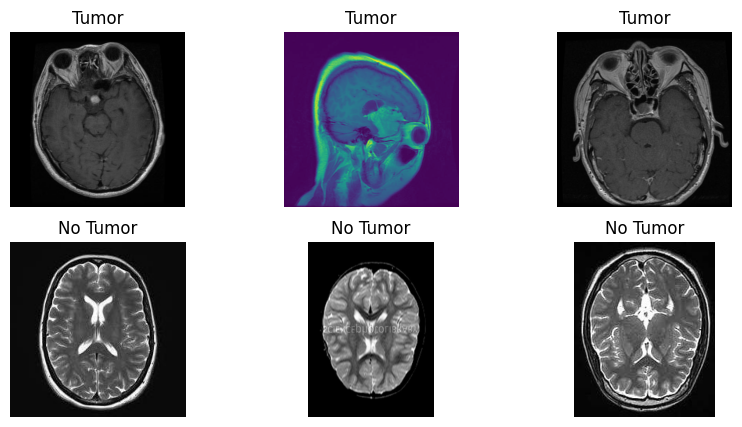

In [16]:
# Show example images from dataset
# Purpose: visually inspect sample MRI images before training the model

from PIL import Image  # Required to open images correctly

plt.figure(figsize=(10,5))

# -----------------------------
# Tumor samples
# -----------------------------
for i, img in enumerate(os.listdir(tumor_folder)[:3]):
    plt.subplot(2,3,i+1)

    # Open and display tumor image
    image = Image.open(os.path.join(tumor_folder, img))
    plt.imshow(image)

    plt.title("Tumor")
    plt.axis("off")

# -----------------------------
# No Tumor samples
# -----------------------------
for i, img in enumerate(os.listdir(notumor_folder)[:3]):
    plt.subplot(2,3,i+4)

    # Open and display non-tumor image
    image = Image.open(os.path.join(notumor_folder, img))
    plt.imshow(image)

    plt.title("No Tumor")
    plt.axis("off")

plt.show()

# WHY?
# To visually understand the dataset distribution and image quality before training

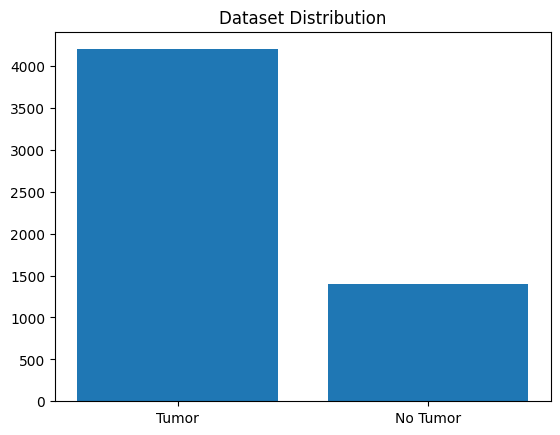

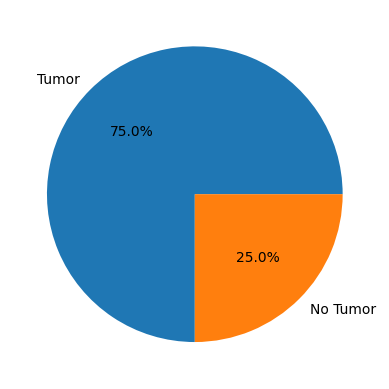

In [17]:
# Bar chart for class distribution

plt.bar(["Tumor","No Tumor"], [tumor_count, notumor_count])
plt.title("Dataset Distribution")
plt.show()

# Pie chart for percentage distribution

plt.pie([tumor_count, notumor_count],
        labels=["Tumor","No Tumor"],
        autopct="%1.1f%%")
plt.show()

# WHY?
# To check dataset balance visually

In [18]:
# Resize images + normalize pixels + split dataset

IMG_SIZE = (224,224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,        # normalize pixel values (0–1)
    validation_split=0.2   # 80% train / 20% validation
)

# Training data
train_data = datagen.flow_from_directory(
    binary_dataset,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training"
)

# Validation data
val_data = datagen.flow_from_directory(
    binary_dataset,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation"
)

# WHY?
# AI models need normalized and fixed-size images for training

Found 4480 images belonging to 2 classes.
Found 1120 images belonging to 2 classes.


In [21]:
# Build custom CNN model from scratch

cnn_model = Sequential()

cnn_model.add(Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Conv2D(64,(3,3),activation='relu'))
cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Flatten())
cnn_model.add(Dense(128,activation='relu'))
cnn_model.add(Dropout(0.5))  # prevents overfitting
cnn_model.add(Dense(1,activation='sigmoid'))  # binary output

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

# WHY?
# CNN learns features directly from images (edges, shapes, patterns)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,521 (91.20 MB)

 Trainable params: 23,907,521 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Train CNN model

history_cnn = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

# WHY?
# Model learns patterns from MRI images

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 456s 3s/step - accuracy: 0.8674 - loss: 0.3866 - val_accuracy: 0.9714 - val_loss: 0.0737
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 452s 3s/step - accuracy: 0.9509 - loss: 0.1450 - val_accuracy: 0.9741 - val_loss: 0.0722
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 448s 3s/step - accuracy: 0.9609 - loss: 0.1229 - val_accuracy: 0.9884 - val_loss: 0.0549
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 437s 3s/step - accuracy: 0.9703 - loss: 0.0803 - val_accuracy: 0.9884 - val_loss: 0.0388
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 456s 3s/step - accuracy: 0.9768 - loss: 0.0628 - val_accuracy: 0.9920 - val_loss: 0.0272
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 451s 3s/step - accuracy: 0.9777 - loss: 0.0589 - val_accuracy: 0.9866 - val_loss: 0.0408
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 447s 3s/step - accuracy: 0.9844 - loss: 0.0407 - val_accuracy: 0.9929 - val_loss: 0.0230
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 435s 3s/step - accuracy: 0.9873 - loss: 0.0318 - val_accu

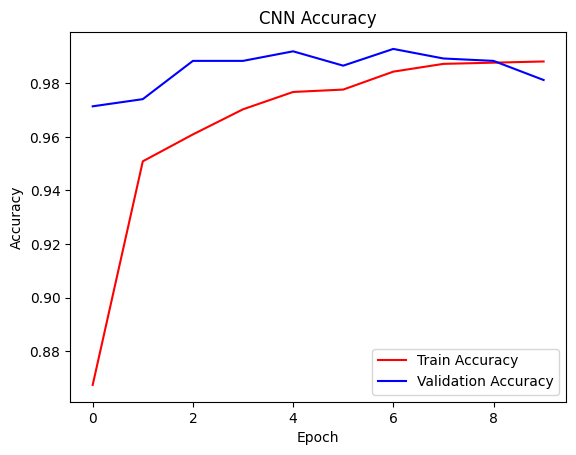

In [23]:
# Plot CNN training and validation accuracy

plt.plot(history_cnn.history['accuracy'],
         color='red',
         label='Train Accuracy')

plt.plot(history_cnn.history['val_accuracy'],
         color='blue',
         label='Validation Accuracy')

plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# WHY?
# To visualize how CNN accuracy changes during training

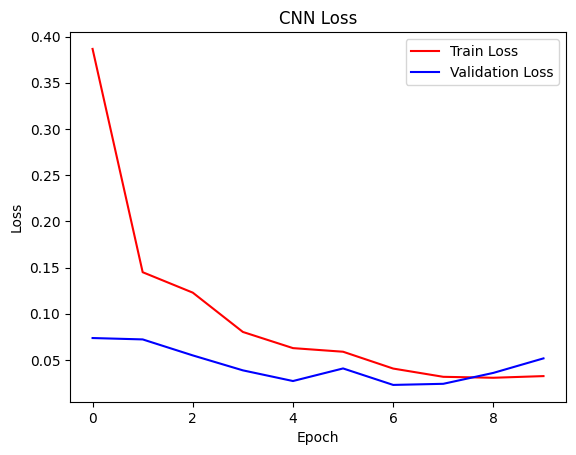

In [24]:
# Plot CNN training and validation loss

plt.plot(history_cnn.history['loss'],
         color='red',
         label='Train Loss')

plt.plot(history_cnn.history['val_loss'],
         color='blue',
         label='Validation Loss')

plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# WHY?
# To monitor CNN learning performance and detect overfitting

In [25]:
cnn_loss, cnn_acc = cnn_model.evaluate(val_data)
print("CNN Accuracy:", cnn_acc)

# WHY?
# To measure how well CNN performs on unseen data

35/35 ━━━━━━━━━━━━━━━━━━━━ 31s 863ms/step - accuracy: 0.9812 - loss: 0.0517
CNN Accuracy: 0.981249988079071


In [26]:
# Load pretrained MobileNetV2 (Transfer Learning)

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False  # freeze pretrained layers

# Add custom classifier
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128,activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1,activation='sigmoid')(x)

mobilenet_model = Model(base_model.input, output)

mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

# WHY?
# Uses pre-trained knowledge from ImageNet for better accuracy

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_24"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [27]:
history_mobile = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

# WHY?
# Fine-tunes pretrained model for medical images

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 250s 2s/step - accuracy: 0.9536 - loss: 0.1376 - val_accuracy: 0.9848 - val_loss: 0.0441
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 280s 2s/step - accuracy: 0.9754 - loss: 0.0737 - val_accuracy: 0.9884 - val_loss: 0.0391
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.9842 - loss: 0.0484 - val_accuracy: 0.9911 - val_loss: 0.0356
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.9868 - loss: 0.0399 - val_accuracy: 0.9937 - val_loss: 0.0263
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 247s 2s/step - accuracy: 0.9875 - loss: 0.0360 - val_accuracy: 0.9902 - val_loss: 0.0368
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 276s 2s/step - accuracy: 0.9884 - loss: 0.0313 - val_accuracy: 0.9929 - val_loss: 0.0288
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.9924 - loss: 0.0228 - val_accuracy: 0.9955 - val_loss: 0.0269
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 242s 2s/step - accuracy: 0.9906 - loss: 0.0218 - val_accu

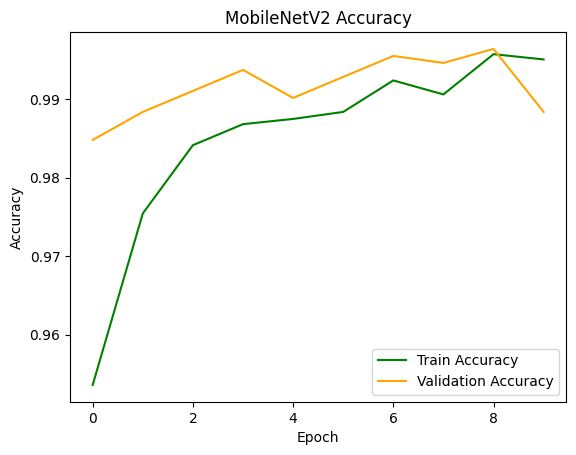

In [28]:
# Plot MobileNetV2 training and validation accuracy

plt.plot(history_mobile.history['accuracy'],
         color='green',
         label='Train Accuracy')

plt.plot(history_mobile.history['val_accuracy'],
         color='orange',
         label='Validation Accuracy')

plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# WHY?
# To visualize MobileNetV2 learning progress

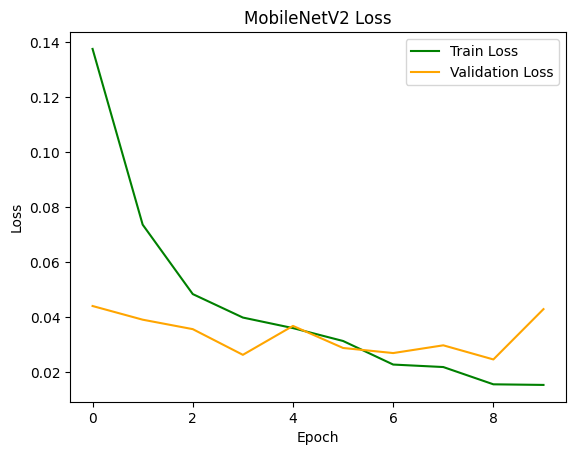

In [29]:
# Plot MobileNetV2 training and validation loss

plt.plot(history_mobile.history['loss'],
         color='green',
         label='Train Loss')

plt.plot(history_mobile.history['val_loss'],
         color='orange',
         label='Validation Loss')

plt.title('MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# WHY?
# To evaluate MobileNetV2 convergence during training

In [30]:
mobile_loss, mobile_acc = mobilenet_model.evaluate(val_data)
print("MobileNetV2 Accuracy:", mobile_acc)

# WHY?
# Compare performance with CNN

35/35 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.9884 - loss: 0.0429
MobileNetV2 Accuracy: 0.9883928298950195


In [31]:
val_data.reset()

y_pred = mobilenet_model.predict(val_data)
y_pred = (y_pred > 0.5).astype(int).reshape(-1)

y_true = val_data.classes

print(confusion_matrix(y_true, y_pred))

# WHY?
# Shows correct vs incorrect predictions

35/35 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step
[[ 75 205]
 [194 646]]


In [32]:
# Create comparison table

comparison = pd.DataFrame({
    'Model': ['CNN', 'MobileNetV2'],
    'Accuracy': [cnn_acc, mobile_acc]
})

print(comparison)

# WHY?
# To compare both models in tabular format

         Model  Accuracy
0          CNN  0.981250
1  MobileNetV2  0.988393


In [53]:
# ==========================================================
# CORRECT EVALUATION PIPELINE
# ==========================================================

# Reset generator
val_data.reset()

# True labels
y_true = val_data.classes

# Predictions
mobile_pred_prob = mobilenet_model.predict(val_data, verbose=0)
mobile_pred = (mobile_pred_prob > 0.5).astype(int).flatten()

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_true, mobile_pred))
print(confusion_matrix(y_true, mobile_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       280
           1       0.99      1.00      0.99       840

    accuracy                           0.99      1120
   macro avg       0.99      0.98      0.98      1120
weighted avg       0.99      0.99      0.99      1120

[[268  12]
 [  1 839]]


In [55]:
# IMPORTANT: reset once
val_data.reset()

# TRUE LABELS (fixed order)
y_true = val_data.classes

# PREDICTIONS (must match same generator order)
y_pred = (cnn_model.predict(val_data, verbose=0) > 0.5).astype(int).flatten()
# REPORT
print(classification_report(y_true, y_pred, target_names=['No Tumor', 'Tumor']))

              precision    recall  f1-score   support

    No Tumor       1.00      0.93      0.96       280
       Tumor       0.98      1.00      0.99       840

    accuracy                           0.98      1120
   macro avg       0.99      0.96      0.97      1120
weighted avg       0.98      0.98      0.98      1120



In [35]:
img_path = os.path.join(tumor_folder, random.choice(os.listdir(tumor_folder)))

img = load_img(img_path, target_size=(224,224))
x = img_to_array(img)/255.0
x = np.expand_dims(x, axis=0)

pred = mobilenet_model.predict(x)[0][0]

print("Prediction:",
      "Tumor" if pred > 0.5 else "No Tumor")

# WHY?
# Test model on a single real image

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: Tumor


In [56]:
# Generate CNN classification report

print("CNN Classification Report")

print(
    classification_report(
        y_true,
        cnn_pred
    )
)

# WHY?
# Provides Precision, Recall and F1-Score for CNN

CNN Classification Report
              precision    recall  f1-score   support

           0       1.00      0.93      0.96       280
           1       0.98      1.00      0.99       840

    accuracy                           0.98      1120
   macro avg       0.99      0.96      0.97      1120
weighted avg       0.98      0.98      0.98      1120



In [4]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [57]:
# ==========================================================
# PERFORMANCE COMPARISON: CNN vs MobileNetV2
# ==========================================================

# Import evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Reset validation generator (important for correct predictions order)
val_data.reset()

# ==========================================================
# CNN Predictions
# ==========================================================
cnn_pred_prob = cnn_model.predict(val_data, verbose=0)
cnn_pred = (cnn_pred_prob > 0.5).astype(int).flatten()

# ==========================================================
# MobileNetV2 Predictions
# ==========================================================
mobile_pred_prob = mobilenet_model.predict(val_data, verbose=0)
mobile_pred = (mobile_pred_prob > 0.5).astype(int).flatten()

# ==========================================================
# True Labels
# ==========================================================
true_labels = val_data.classes

# ==========================================================
# CNN Metrics
# ==========================================================
cnn_accuracy = accuracy_score(true_labels, cnn_pred)
cnn_precision = precision_score(true_labels, cnn_pred)
cnn_recall = recall_score(true_labels, cnn_pred)
cnn_f1 = f1_score(true_labels, cnn_pred)

# ==========================================================
# MobileNetV2 Metrics
# ==========================================================
mobile_accuracy = accuracy_score(true_labels, mobile_pred)
mobile_precision = precision_score(true_labels, mobile_pred)
mobile_recall = recall_score(true_labels, mobile_pred)
mobile_f1 = f1_score(true_labels, mobile_pred)

# ==========================================================
# PRINT RESULTS
# ==========================================================
print("="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)

print("\nCNN RESULTS:")
print(f"Accuracy : {cnn_accuracy*100:.2f}%")
print(f"Precision: {cnn_precision*100:.2f}%")
print(f"Recall   : {cnn_recall*100:.2f}%")
print(f"F1-Score : {cnn_f1*100:.2f}%")

print("\nMobileNetV2 RESULTS:")
print(f"Accuracy : {mobile_accuracy*100:.2f}%")
print(f"Precision: {mobile_precision*100:.2f}%")
print(f"Recall   : {mobile_recall*100:.2f}%")
print(f"F1-Score : {mobile_f1*100:.2f}%")

MODEL PERFORMANCE COMPARISON

CNN RESULTS:
Accuracy : 98.12%
Precision: 97.67%
Recall   : 99.88%
F1-Score : 98.76%

MobileNetV2 RESULTS:
Accuracy : 98.84%
Precision: 98.59%
Recall   : 99.88%
F1-Score : 99.23%


In [58]:
import pandas as pd

comparison_data = {
    'Metric': ['Accuracy','Precision','Recall','F1-Score'],

    'CNN': [
        f'{cnn_accuracy*100:.2f}%',
        f'{cnn_precision*100:.2f}%',
        f'{cnn_recall*100:.2f}%',
        f'{cnn_f1*100:.2f}%'
    ],

    'MobileNetV2': [
        f'{mobile_accuracy*100:.2f}%',
        f'{mobile_precision*100:.2f}%',
        f'{mobile_recall*100:.2f}%',
        f'{mobile_f1*100:.2f}%'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Metric,CNN,MobileNetV2
0,Accuracy,98.12%,98.84%
1,Precision,97.67%,98.59%
2,Recall,99.88%,99.88%
3,F1-Score,98.76%,99.23%


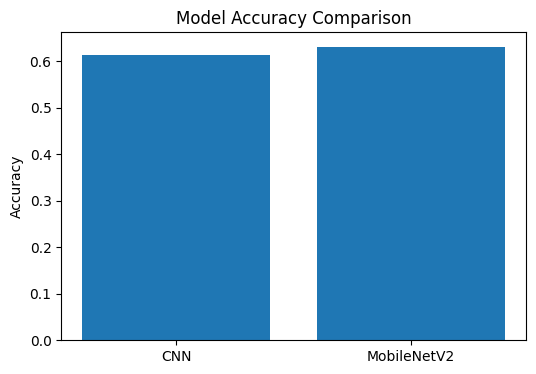

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    ['CNN', 'MobileNetV2'],
    [cnn_accuracy, mobile_accuracy]
)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

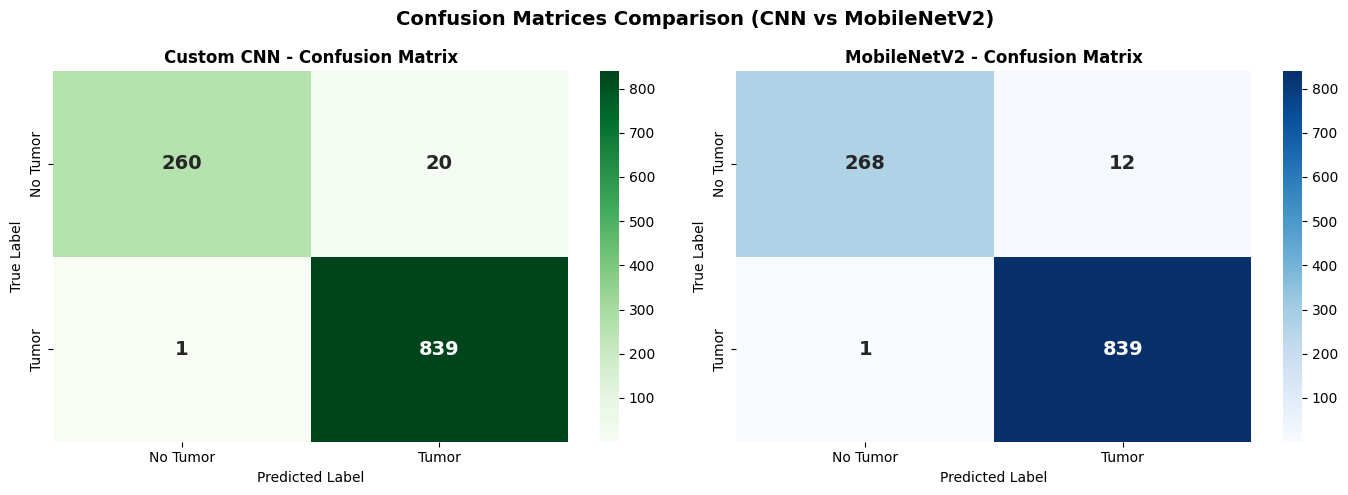


CONFUSION MATRIX INTERPRETATION

Custom CNN:
True Negatives  (No Tumor correctly identified): 260
False Positives (No Tumor predicted as Tumor):   20
False Negatives (Tumor predicted as No Tumor):   1
True Positives  (Tumor correctly identified):     839

MobileNetV2:
True Negatives  (No Tumor correctly identified): 268
False Positives (No Tumor predicted as Tumor):   12
False Negatives (Tumor predicted as No Tumor):   1
True Positives  (Tumor correctly identified):     839


In [59]:
# ==========================================================
# CONFUSION MATRIX COMPARISON
# CNN vs MobileNetV2
# ==========================================================
# WHY?
# To evaluate model performance beyond accuracy

import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==========================================================
# Reset validation data (IMPORTANT)
# ==========================================================
val_data.reset()

# CNN predictions
cnn_pred = (cnn_model.predict(val_data, verbose=0) > 0.5).astype(int).flatten()

val_data.reset()

# MobileNetV2 predictions
mobile_pred = (mobilenet_model.predict(val_data, verbose=0) > 0.5).astype(int).flatten()

# True labels
true_labels = val_data.classes

# ==========================================================
# Confusion Matrices
# ==========================================================
cm_cnn = confusion_matrix(true_labels, cnn_pred)
cm_mobile = confusion_matrix(true_labels, mobile_pred)

class_names = ['No Tumor', 'Tumor']

# ==========================================================
# Plot Confusion Matrices
# ==========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------- CNN ----------------
sns.heatmap(
    cm_cnn,
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[0],
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={'size': 14, 'weight': 'bold'}
)

axes[0].set_title('Custom CNN - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# ---------------- MobileNetV2 ----------------
sns.heatmap(
    cm_mobile,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1],
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={'size': 14, 'weight': 'bold'}
)

axes[1].set_title('MobileNetV2 - Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.suptitle('Confusion Matrices Comparison (CNN vs MobileNetV2)',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================================
# CONFUSION MATRIX INTERPRETATION
# ==========================================================
# WHY?
# This is important for IEEE report discussion section

print("\n" + "=" * 60)
print("CONFUSION MATRIX INTERPRETATION")
print("=" * 60)

print("\nCustom CNN:")

print(f"True Negatives  (No Tumor correctly identified): {cm_cnn[0][0]}")
print(f"False Positives (No Tumor predicted as Tumor):   {cm_cnn[0][1]}")
print(f"False Negatives (Tumor predicted as No Tumor):   {cm_cnn[1][0]}")
print(f"True Positives  (Tumor correctly identified):     {cm_cnn[1][1]}")

print("\nMobileNetV2:")

print(f"True Negatives  (No Tumor correctly identified): {cm_mobile[0][0]}")
print(f"False Positives (No Tumor predicted as Tumor):   {cm_mobile[0][1]}")
print(f"False Negatives (Tumor predicted as No Tumor):   {cm_mobile[1][0]}")
print(f"True Positives  (Tumor correctly identified):     {cm_mobile[1][1]}")

print("=" * 60)

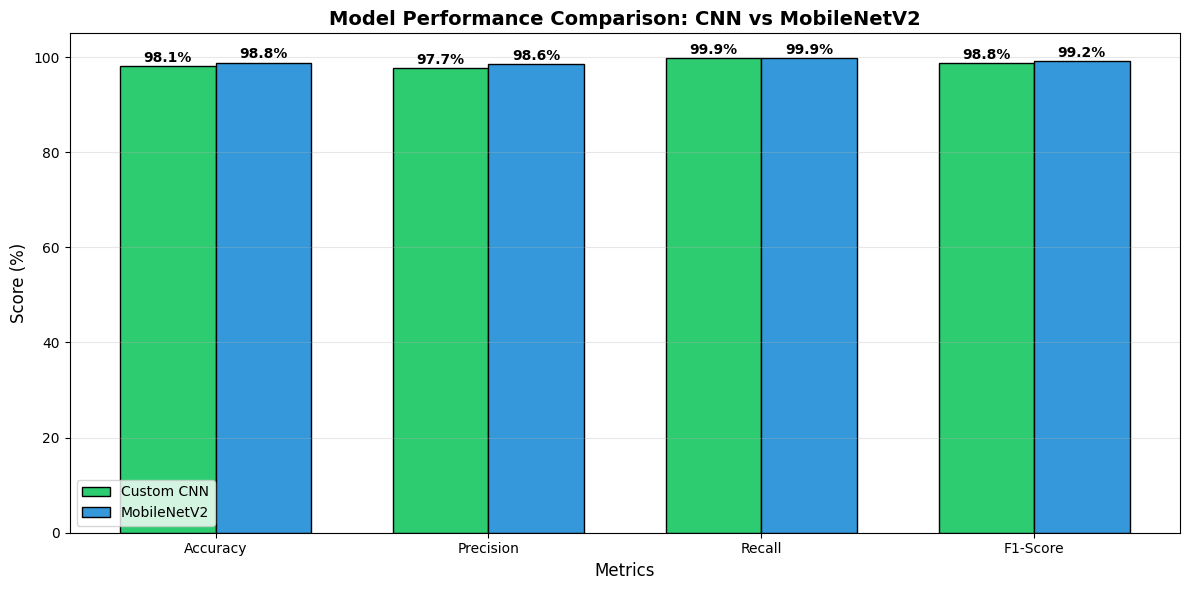

In [60]:
# ==========================================================
# MODEL PERFORMANCE COMPARISON (CNN vs MobileNetV2)
# ==========================================================
# WHY?
# To compare models using multiple evaluation metrics visually

import numpy as np
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# CNN scores (from your evaluation section)
cnn_scores = [
    cnn_accuracy * 100,
    cnn_precision * 100,
    cnn_recall * 100,
    cnn_f1 * 100
]

# MobileNetV2 scores
mobile_scores = [
    mobile_accuracy * 100,
    mobile_precision * 100,
    mobile_recall * 100,
    mobile_f1 * 100
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

# CNN bars
bars1 = ax.bar(
    x - width/2,
    cnn_scores,
    width,
    label='Custom CNN',
    color='#2ecc71',
    edgecolor='black'
)

# MobileNetV2 bars
bars2 = ax.bar(
    x + width/2,
    mobile_scores,
    width,
    label='MobileNetV2',
    color='#3498db',
    edgecolor='black'
)

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Performance Comparison: CNN vs MobileNetV2',
             fontsize=14, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim([0, 105])
ax.grid(axis='y', alpha=0.3)

# Add values on bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(
        f'{height:.1f}%',
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [61]:
# ==========================================================
# DETAILED CLASSIFICATION REPORT
# CNN vs MobileNetV2
# ==========================================================
# WHY?
# Provides Precision, Recall, F1-score per class (very important for IEEE report)

from sklearn.metrics import classification_report

# ==========================================================
# Make sure predictions exist
# ==========================================================
# true_labels must already be defined from val_data
# cnn_pred and mobile_pred must already be generated

print("=" * 60)
print("DETAILED CLASSIFICATION REPORT - CUSTOM CNN")
print("=" * 60)

print(
    classification_report(
        true_labels,
        cnn_pred,
        target_names=['No Tumor', 'Tumor']
    )
)

print("\n" + "=" * 60)
print("DETAILED CLASSIFICATION REPORT - MobileNetV2")
print("=" * 60)

print(
    classification_report(
        true_labels,
        mobile_pred,
        target_names=['No Tumor', 'Tumor']
    )
)

DETAILED CLASSIFICATION REPORT - CUSTOM CNN
              precision    recall  f1-score   support

    No Tumor       1.00      0.93      0.96       280
       Tumor       0.98      1.00      0.99       840

    accuracy                           0.98      1120
   macro avg       0.99      0.96      0.97      1120
weighted avg       0.98      0.98      0.98      1120


DETAILED CLASSIFICATION REPORT - MobileNetV2
              precision    recall  f1-score   support

    No Tumor       1.00      0.96      0.98       280
       Tumor       0.99      1.00      0.99       840

    accuracy                           0.99      1120
   macro avg       0.99      0.98      0.98      1120
weighted avg       0.99      0.99      0.99      1120



In [49]:
# ==========================================================
# FINAL EVALUATION (CORRECT RESULTS)
# Using shuffle=False
# ==========================================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ==========================================================
# Create evaluation dataset without shuffling
# ==========================================================

eval_data = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_data_eval = eval_data.flow_from_directory(
    binary_dataset,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

# ==========================================================
# True Labels
# ==========================================================

true_labels = val_data_eval.classes

# ==========================================================
# CNN Predictions
# ==========================================================

cnn_pred = cnn_model.predict(
    val_data_eval,
    verbose=0
)

cnn_pred = (cnn_pred > 0.5).astype(int).flatten()

# ==========================================================
# MobileNetV2 Predictions
# ==========================================================

mobile_pred = mobilenet_model.predict(
    val_data_eval,
    verbose=0
)

mobile_pred = (mobile_pred > 0.5).astype(int).flatten()

# ==========================================================
# CNN Metrics
# ==========================================================

cnn_accuracy = accuracy_score(
    true_labels,
    cnn_pred
)

cnn_precision = precision_score(
    true_labels,
    cnn_pred
)

cnn_recall = recall_score(
    true_labels,
    cnn_pred
)

cnn_f1 = f1_score(
    true_labels,
    cnn_pred
)

# ==========================================================
# MobileNetV2 Metrics
# ==========================================================

mobile_accuracy = accuracy_score(
    true_labels,
    mobile_pred
)

mobile_precision = precision_score(
    true_labels,
    mobile_pred
)

mobile_recall = recall_score(
    true_labels,
    mobile_pred
)

mobile_f1 = f1_score(
    true_labels,
    mobile_pred
)

# ==========================================================
# Print Results
# ==========================================================

print("="*60)
print("FINAL MODEL PERFORMANCE")
print("="*60)

print("\nCNN RESULTS")
print(f"Accuracy : {cnn_accuracy*100:.2f}%")
print(f"Precision: {cnn_precision*100:.2f}%")
print(f"Recall   : {cnn_recall*100:.2f}%")
print(f"F1-Score : {cnn_f1*100:.2f}%")

print("\nMobileNetV2 RESULTS")
print(f"Accuracy : {mobile_accuracy*100:.2f}%")
print(f"Precision: {mobile_precision*100:.2f}%")
print(f"Recall   : {mobile_recall*100:.2f}%")
print(f"F1-Score : {mobile_f1*100:.2f}%")

# ==========================================================
# CNN Classification Report
# ==========================================================

print("\n" + "="*60)
print("CNN CLASSIFICATION REPORT")
print("="*60)

print(
    classification_report(
        true_labels,
        cnn_pred,
        target_names=['No Tumor', 'Tumor']
    )
)

# ==========================================================
# MobileNetV2 Classification Report
# ==========================================================

print("\n" + "="*60)
print("MobileNetV2 CLASSIFICATION REPORT")
print("="*60)

print(
    classification_report(
        true_labels,
        mobile_pred,
        target_names=['No Tumor', 'Tumor']
    )
)

# ==========================================================
# Confusion Matrices
# ==========================================================

cnn_cm = confusion_matrix(
    true_labels,
    cnn_pred
)

mobile_cm = confusion_matrix(
    true_labels,
    mobile_pred
)

print("\nCNN Confusion Matrix")
print(cnn_cm)

print("\nMobileNetV2 Confusion Matrix")
print(mobile_cm)

Found 1120 images belonging to 2 classes.
FINAL MODEL PERFORMANCE

CNN RESULTS
Accuracy : 98.12%
Precision: 97.67%
Recall   : 99.88%
F1-Score : 98.76%

MobileNetV2 RESULTS
Accuracy : 98.84%
Precision: 98.59%
Recall   : 99.88%
F1-Score : 99.23%

CNN CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Tumor       1.00      0.93      0.96       280
       Tumor       0.98      1.00      0.99       840

    accuracy                           0.98      1120
   macro avg       0.99      0.96      0.97      1120
weighted avg       0.98      0.98      0.98      1120


MobileNetV2 CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Tumor       1.00      0.96      0.98       280
       Tumor       0.99      1.00      0.99       840

    accuracy                           0.99      1120
   macro avg       0.99      0.98      0.98      1120
weighted avg       0.99      0.99      0.99      1120


CNN Confusion Matrix
[[260  20]
 [  1 8

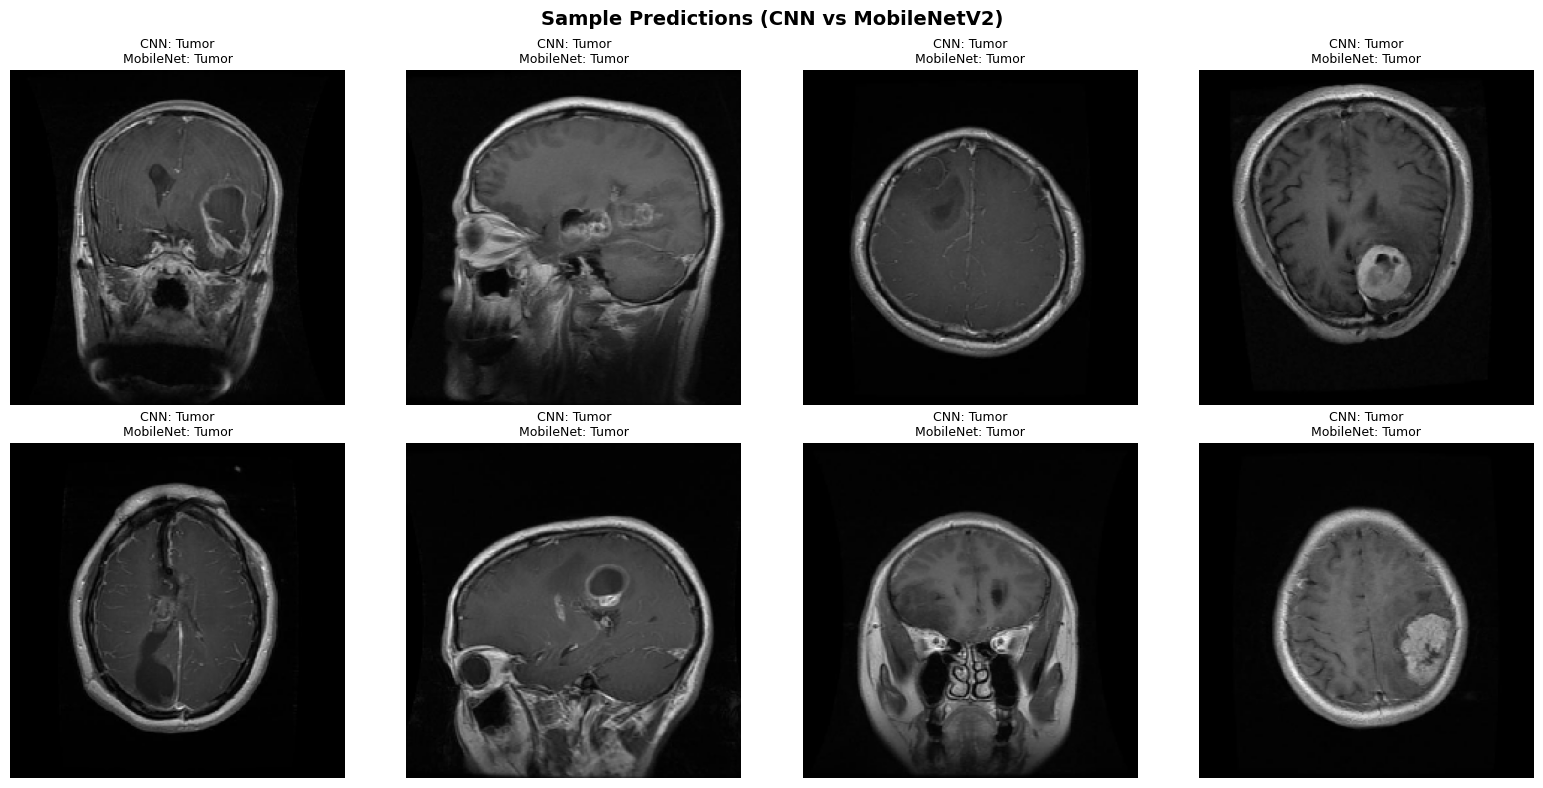

In [45]:
# ==========================================================
# SAMPLE PREDICTIONS VISUALIZATION
# ==========================================================
# WHY?
# To show real model behavior on unseen images

val_data.reset()

sample_batch = next(iter(val_data))

images = sample_batch[0][:8]

cnn_preds = (cnn_model.predict(images, verbose=0) > 0.5).astype(int).flatten()
mobile_preds = (mobilenet_model.predict(images, verbose=0) > 0.5).astype(int).flatten()

class_map = {0: "No Tumor", 1: "Tumor"}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i])

    ax.set_title(
        f"CNN: {class_map[cnn_preds[i]]}\nMobileNet: {class_map[mobile_preds[i]]}",
        fontsize=9
    )

    ax.axis("off")

plt.suptitle("Sample Predictions (CNN vs MobileNetV2)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [1]:
!ls /content

sample_data
